<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/wip-mnist-generation-dcgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating MNIST with DCGANs (Deep Convolutional Generative Adversarial Networks)

**Note:** This notebook is a work in progress. GAN training remains unstable.

In this notebook, we'll train a generator network to create new MNIST-like digits using a Generative Adversarial Network (GAN).

A GAN consists of two models:
- **Generator:** Takes random noise as input and tries to produce images that resemble real MNIST digits, aiming to fool the Discriminator.
- **Discriminator:** Attempts to distinguish between real MNIST images (from the dataset) and fake images (produced by the Generator or unrelated sources).

Both models start from scratch and improve iteratively by challenging each other. This adversarial process is crucial: if one model becomes too strong, the other can't learn effectively. Training a Generator against a pre-trained Discriminator is ineffective, as the Generator's initial outputs are too poor to provide meaningful feedback.

Training GANs is challenging because both models must evolve at a similar pace. If the Discriminator becomes too good, it provides no useful gradient (feedback) to the Generator, stalling its learning. Conversely, if the Generator dominates, the Discriminator's predictions become random, halting its progress. Unlike supervised learning, where clear targets and stable gradients guide improvement, GANs require a delicate balance between the two models.

For more details, see: https://paperswithcode.com/method/dcgan


## Setup

First, install the required packages:


In [41]:
!pip install torch
!pip install matplotlib
!pip install tsilva-notebook-utils
!pip install huggingface_hub

Next, select the device to use (GPU if available, otherwise CPU):


In [42]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

Let's define the hyperparameters:

In [43]:
IMAGE_WIDTH, IMAGE_HEIGHT = 28, 28
CONFIG = {
    "seed" : 42,
    "latent_dim": 512,          # Size of the random noise vector input to the generator
    "epochs": 50,               # Number of times the entire dataset is passed through the network
    "batch_size": 512,          # Number of samples processed before updating model parameters
    "g_learning_rate": 2e-4,
    "d_learning_rate": 1e-4     # Step size for parameter updates during optimization
}

Set the random seed for reproducibility:


In [44]:
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)  # Set the seed for Python's built-in random number generator
    np.random.seed(seed)  # Set the seed for NumPy's random number generator
    torch.manual_seed(seed)  # Set the seed for PyTorch's CPU random number generator
    torch.cuda.manual_seed(seed)  # Set the seed for PyTorch's CUDA (GPU) random number generator, if GPU is available
    torch.backends.cudnn.deterministic = True  # Force CuDNN (CUDA Deep Neural Network library) to use deterministic algorithms for reproducibility
    torch.backends.cudnn.benchmark = False  # Disable CuDNN's benchmarking feature, which optimizes for speed but may introduce randomness

seed = CONFIG["seed"]
set_seed(seed)

## Prepare Dataset

In [45]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(
    root='data',
    train=True,
    transform=transform,
    download=True
)
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

Create a DataLoader to sample batches from the dataset:


In [46]:
import multiprocessing
from torch.utils.data import DataLoader

batch_size = CONFIG["batch_size"]

dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=multiprocessing.cpu_count(),
    pin_memory=True
)

for X, Y in dataloader:
    print(f"X shape: {X.shape}")
    print(f"Y shape: {Y.shape}")
    break

X shape: torch.Size([512, 1, 28, 28])
Y shape: torch.Size([512])


## Build Generator Model

Let's build the generator: a small model that takes a noise vector as input and transforms it through hidden layers to produce an image.


In [47]:
import torch.nn as nn

def weights_init_normal(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

def build_generator_model(latent_dim=None):
    if latent_dim is None: latent_dim = CONFIG["latent_dim"]

    # Build generator model using tips from DCGAN paper with added spectral normalization
    image_dim = IMAGE_WIDTH * IMAGE_HEIGHT
    generator = nn.Sequential(
        # Project noise to a 7x7x128 feature map with spectral normalization
        nn.utils.spectral_norm(nn.Linear(latent_dim, 128 * 7 * 7)),
        nn.BatchNorm1d(128 * 7 * 7),
        nn.ReLU(True),

        # Reshape to (batch_size, 128, 7, 7)
        nn.Unflatten(1, (128, 7, 7)),

        # Upsample to 14x14 with spectral normalization
        nn.utils.spectral_norm(nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False)),
        nn.BatchNorm2d(64),
        nn.ReLU(True),

        # Upsample to 28x28 with spectral normalization
        nn.utils.spectral_norm(nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=False)),
        nn.Tanh()  # Output range [-1, 1] to match MNIST normalization
    )
    return generator

# Build generator model and send it to device (eg: GPU)
G = build_generator_model()
G.apply(weights_init_normal)
G = G.to(DEVICE)

Let's sample some images from the generator:


In [48]:
def generate_images(model, n_samples, latent_dim=None):
    if latent_dim is None: latent_dim = CONFIG["latent_dim"]

    G.eval()

    noise = torch.randn(n_samples, latent_dim).to(DEVICE)
    with torch.no_grad(): images = G(noise)
    images = images.view(images.size(0), 1, IMAGE_WIDTH, IMAGE_HEIGHT)
    return images

generated_images = generate_images(G, 6)
generated_images.shape

torch.Size([6, 1, 28, 28])

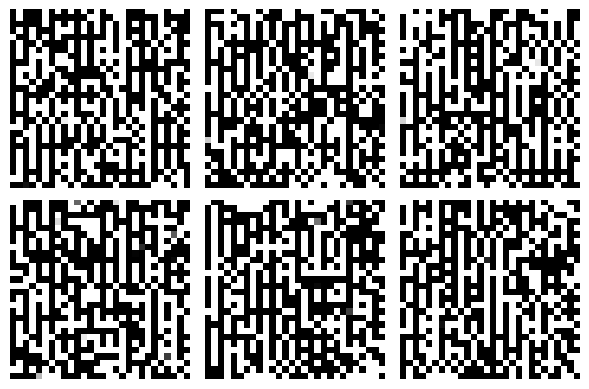

In [49]:
import matplotlib.pyplot as plt
import math

def plot_generated_images(images, n_columns=3):
    n_rows = math.ceil(images.shape[0] / n_columns)  # Auto-calculate rows
    plt.figure(figsize=(n_columns * 2, n_rows * 2))

    for i in range(images.shape[0]):
        plt.subplot(n_rows, n_columns, i+1)
        plt.imshow(images[i].squeeze().detach().cpu().numpy(), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_generated_images(generated_images, n_columns=3)  # Example usage

## Build Discriminator Model

Now, let's build the discriminator: a model that takes an image as input and outputs a single value representing the probability that the image is real (from the dataset).


In [50]:
def build_discriminator_model():
    # Build discriminator model using tips from DCGAN paper:
    # - Dont use pooling layers, use strided convolutions instead
    # - Use batchnorm
    # - Dont use fully connected hidden layers
    # - Use LeakyReLU
    image_dim = IMAGE_WIDTH * IMAGE_HEIGHT
    model = nn.Sequential(
        # Downsample to 14x14
        nn.utils.spectral_norm(nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False)),
        nn.LeakyReLU(0.2, inplace=True),

        # Downsample to 7x7
        nn.utils.spectral_norm(nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False)),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2, inplace=True),

        # Flatten and output probability
        nn.Flatten(),
        nn.utils.spectral_norm(nn.Linear(128 * 7 * 7, 1))  # No sigmoid, BCEWithLogitsLoss handles it
    )
    return model

# Build discriminator model and send it to device (eg: GPU)
D = build_discriminator_model()
D.apply(weights_init_normal)
D = D.to(DEVICE)

In [51]:
with torch.no_grad():
    for x, y in dataloader:
        x = x.to(DEVICE)#squeeze().view(-1, IMAGE_WIDTH * IMAGE_HEIGHT).to(DEVICE)
        outputs = D(x)
        print(torch.mean(outputs))
        break

tensor(-0.5605, device='cuda:0')


## Train

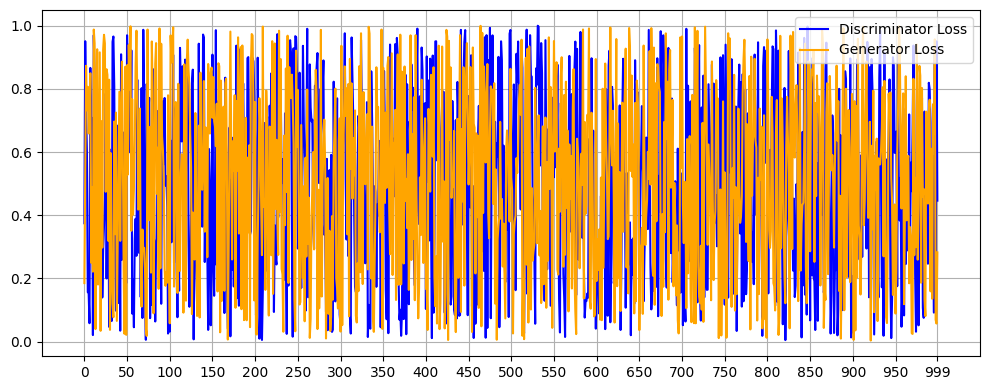

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def plot_losses(d_losses, g_losses):
    epochs = np.arange(len(d_losses))
    n_ticks = min(20, max(10, int(np.ceil(len(d_losses) / 50))))
    step = max(1, int(np.ceil(len(d_losses) / n_ticks)))
    ticks = np.append(np.arange(0, len(d_losses), step), len(d_losses) - 1)
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.plot(epochs, d_losses, label='Discriminator Loss', color='blue')
    ax.plot(epochs, g_losses, label='Generator Loss', color='orange')
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(int(t)) for t in ticks])
    ax.legend(); ax.grid(); plt.tight_layout(); plt.show()

plot_losses(np.random.rand(1000), np.random.rand(1000))

Now let's train the GAN:


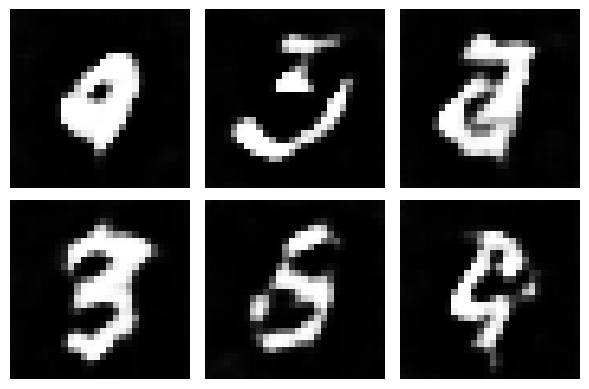

In [ ]:
import tqdm
import numpy as np
from IPython.display import clear_output

# Retrieve config values
n_epochs = CONFIG["epochs"]
latent_dim = CONFIG["latent_dim"]
g_learning_rate = CONFIG["g_learning_rate"]
d_learning_rate = CONFIG["d_learning_rate"]

# Create generator optimizer
g_optimizer = torch.optim.Adam(
    G.parameters(),
    lr=g_learning_rate,
    betas=(0.5, 0.999)
)

# Create discriminator optimizer
d_optimizer = torch.optim.Adam(
    D.parameters(),
    lr=d_learning_rate,
    betas=(0.5, 0.999)
)

# Create loss function (binary cross entropy loss)
loss_fn = nn.BCEWithLogitsLoss()

# Train for N epochs
epoch_d_losses = []
epoch_g_losses = []
epoch_d_loss = None
epoch_g_loss = None
for epoch in range(n_epochs):
    G.train()
    D.train()

    # Sample minibatch and perform optimization step
    batch_d_losses = []
    batch_g_losses = []

    for real_images, _ in tqdm.tqdm(
        dataloader,
        desc=f"Epoch {epoch+1}/{n_epochs}" + (f" (d_loss: {epoch_d_loss:.3f}, g_loss: {epoch_g_loss:.3f})" if epoch > 0 else ""),
        leave=False
    ):
        # Send batch to device (eg: GPU)
        real_images = real_images.to(DEVICE)

        # Create the labels we are going to use for loss
        # calculation, real images are labeled as 1s and
        # fake images are labeled as 0s
        batch_size = real_images.size(0)
        real_labels = torch.full((batch_size, 1), 0.9).to(DEVICE)
        fake_labels = torch.full((batch_size, 1), 1.0).to(DEVICE)

        #########
        # 1 - Evaluate discriminator loss at classifying real images as being real
        #########

        # Zero out the discriminator gradients to prevent
        # gradient accumulation between epochs
        d_optimizer.zero_grad()

        # Run batch of real images through
        # discriminator and get its predictions
        real_preds = D(real_images)

        # Calculate the discriminator loss
        # at classifying real images as real
        d_loss_real = loss_fn(real_preds, real_labels)

        #########
        # 2 - Evaluate discriminator loss at classifying fake images as being fake
        #########

        # Generate N instances of noise with the size of the
        # generator's input layer and send it to device (eg: GPU)
        noise = torch.randn(batch_size, latent_dim).to(DEVICE)

        # Send noise through generator
        # to get batch of fake images as output
        fake_images = G(noise)

        # Run batch of fake images through
        # discriminator to get its predictions
        fake_preds = D(fake_images.detach())

        # Calculate the discriminator loss
        # at classifying fake images as fake
        d_loss_fake = loss_fn(fake_preds, fake_labels)

        # Calculate the final discriminator loss, which is the sum of its
        # loss at classifying real images as real and fake images as fake
        # (we want it to become better at both tasks)
        d_loss = d_loss_real + d_loss_fake

        # Backpropagate loss through discriminator model to
        # calculate parameter gradients with respect to loss
        d_loss.backward()

        #torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)

        # Perform optimization step on discriminator model
        # using calculated gradients to adjust model parameters
        # in attempt to reduce loss next time (become better at classifying images)
        d_optimizer.step()

        #########
        # 4 - Adjust generator to improve its ability to generate fake images
        #########

        # Zero out the generator gradients to prevent
        # gradient accumulation between epochs
        g_optimizer.zero_grad()

        #noise = torch.randn(batch_size, latent_dim).to(DEVICE)
        #fake_images = G(noise)

        # Run batch of fake images through
        # discriminator to get its predictions
        fake_preds = D(fake_images)

        # Calculate the generator loss, which corresponds to
        # how far the discriminator was from classifying fake
        # images as real images
        g_loss = loss_fn(fake_preds, real_labels)

        # Backpropagate loss through generator model to
        # calculate parameter gradients with respect to loss
        # (NOTE: loss resulted from discriminator model, but
        # since images were generated through generator, there
        # is computation graph connecting that generation, through
        # discrimination, to loss calculation, which means that we
        # can backpropagate that loss all the way to the generator model)
        g_loss.backward()

        # Perform optimization step on generator model
        # using calculated gradients to adjust model parameters
        # in attempt to reduce loss next time (become better at generating fake images)
        # (NOTE: since this optimizer is bound to the generator's parameters only, this
        # optimization step will not affect the discriminator, even though the loss was
        # backpropagated through it as well)
        g_optimizer.step()

        # Collect batch losses
        batch_d_losses.append(d_loss.item())
        batch_g_losses.append(g_loss.item())

    # Calculate and collect epoch losses
    epoch_d_loss = np.array(batch_d_losses).mean()
    epoch_g_loss = np.array(batch_g_losses).mean()
    epoch_d_losses.append(epoch_d_loss)
    epoch_g_losses.append(epoch_g_loss)

    # Clear the output cell
    clear_output(wait=True)

    # Generate 3 images and show them
    generated_images = generate_images(G, 6)
    plot_generated_images(generated_images)

    # Plot training losses
    plot_losses(epoch_d_losses, epoch_g_losses)

## Evaluate

Now we can use our model to generate new digits each time:


In [ ]:
from tsilva_notebook_utils import render_video

In [ ]:
generated_images = generate_images(G, 6)
plot_generated_images(generated_images)

In [ ]:
generated_images = generate_images(G, 1000)
_generated_images = generated_images.squeeze().detach().cpu().numpy()
_generated_images = (_generated_images + 1) / 2
_generated_images = _generated_images * 255
_generated_images = _generated_images.astype(np.uint8)
render_video(_generated_images, scale=4, fps=5)

## Upload model

In [ ]:
from huggingface_hub import HfApi, login

# Log in to Hugging Face (you'll need a token from your account)
login(token="your_hf_token_here")

# Save the models locally
torch.save(G.state_dict(), "generator.pth")
torch.save(D.state_dict(), "discriminator.pth")

# Upload to Hugging Face Model Hub
api = HfApi()
api.upload_file(
    path_or_fileobj="generator.pth",
    path_in_repo="generator.pth",
    repo_id="your_username/mnist-gan",
    repo_type="model",
)
api.upload_file(
    path_or_fileobj="discriminator.pth",
    path_in_repo="discriminator.pth",
    repo_id="your_username/mnist-gan",
    repo_type="model",
)

## References

- https://paperswithcode.com/method/dcgan
- https://machinelearningmastery.com/how-to-train-stable-generative-adversarial-networks/